In [12]:
import os
import pickle
import json
import numpy as np
import faiss
import torch
import whisper
import time
import sounddevice as sd
from scipy.io.wavfile import write
from sentence_transformers import SentenceTransformer
from collections import defaultdict

# ============================================================
# STEP 1 — LOAD ALL SAVED MODELS EXPLICITLY
# This guarantees search functions always use saved models
# regardless of what was run before in the session
# ============================================================

SAVE_DIR = "saved_models"

def load_all_models(save_dir=SAVE_DIR):
    """
    Explicitly loads all saved models and artifacts from disk.
    Call this once before using any search function.
    
    Returns:
        dict with all loaded components
    """
    
    print("="*50)
    print("   LOADING ALL SAVED MODELS")
    print("="*50)
    
    # verify save directory exists
    if not os.path.exists(save_dir):
        raise FileNotFoundError(
            f"Save directory '{save_dir}' not found.\n"
            f"Please run the Save Cell first to save your models."
        )
    
    components = {}
    
    # ----------------------------------------------------------
    # Load Config
    # ----------------------------------------------------------
    config_path = os.path.join(save_dir, "config.json")
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"config.json not found in {save_dir}")
    
    with open(config_path, "r") as f:
        components["config"] = json.load(f)
    
    cfg = components["config"]
    print(f"\n✅ Config loaded")
    print(f"   Model    : {cfg['EMBEDDING_MODEL']}")
    print(f"   Whisper  : {cfg['WHISPER_MODEL']}")
    print(f"   Captions : {cfg['total_captions']}")
    print(f"   Images   : {cfg['total_images']}")
    
    # ----------------------------------------------------------
    # Load Embedding Model (MiniLM)
    # ----------------------------------------------------------
    embed_path = os.path.join(save_dir, "embedding_model")
    if not os.path.exists(embed_path):
        raise FileNotFoundError(f"Embedding model not found at {embed_path}")
    
    components["embed_model"] = SentenceTransformer(embed_path)
    print(f"\n✅ Embedding model loaded  ← {embed_path}/")
    
    # ----------------------------------------------------------
    # Load Whisper Model
    # ----------------------------------------------------------
    whisper_path = os.path.join(save_dir, "whisper_model.pt")
    if not os.path.exists(whisper_path):
        raise FileNotFoundError(f"Whisper model not found at {whisper_path}")
    
    speech_mdl = whisper.load_model(cfg["WHISPER_MODEL"])
    speech_mdl.load_state_dict(
        torch.load(whisper_path, map_location="cpu")
    )
    speech_mdl.eval()
    components["speech_model"] = speech_mdl
    print(f"✅ Whisper model loaded    ← {whisper_path}")
    
    # ----------------------------------------------------------
    # Load FAISS Index
    # ----------------------------------------------------------
    faiss_path = os.path.join(save_dir, "caption_index.faiss")
    if not os.path.exists(faiss_path):
        raise FileNotFoundError(f"FAISS index not found at {faiss_path}")
    
    components["index"] = faiss.read_index(faiss_path)
    print(f"✅ FAISS index loaded      ← {components['index'].ntotal} vectors")
    
    # ----------------------------------------------------------
    # Load Caption Embeddings
    # ----------------------------------------------------------
    emb_path = os.path.join(save_dir, "caption_embeddings.npy")
    if not os.path.exists(emb_path):
        raise FileNotFoundError(f"Embeddings not found at {emb_path}")
    
    components["caption_embeddings"] = np.load(emb_path).astype("float32")
    print(f"✅ Embeddings loaded       ← shape {components['caption_embeddings'].shape}")
    
    # ----------------------------------------------------------
    # Load Captions List
    # ----------------------------------------------------------
    captions_path = os.path.join(save_dir, "captions.pkl")
    if not os.path.exists(captions_path):
        raise FileNotFoundError(f"Captions not found at {captions_path}")
    
    with open(captions_path, "rb") as f:
        components["captions"] = pickle.load(f)
    print(f"✅ Captions loaded         ← {len(components['captions'])} captions")
    
    # ----------------------------------------------------------
    # Load Image Paths
    # ----------------------------------------------------------
    img_paths_path = os.path.join(save_dir, "image_paths.pkl")
    if not os.path.exists(img_paths_path):
        raise FileNotFoundError(f"Image paths not found at {img_paths_path}")
    
    with open(img_paths_path, "rb") as f:
        components["image_paths"] = pickle.load(f)
    print(f"✅ Image paths loaded      ← {len(components['image_paths'])} paths")
    
    # ----------------------------------------------------------
    # Load Caption Mapping
    # ----------------------------------------------------------
    mapping_path = os.path.join(save_dir, "image_to_captions.pkl")
    if not os.path.exists(mapping_path):
        raise FileNotFoundError(f"Caption mapping not found at {mapping_path}")
    
    with open(mapping_path, "rb") as f:
        components["image_to_captions"] = defaultdict(
            list, pickle.load(f)
        )
    print(f"✅ Caption mapping loaded  ← {len(components['image_to_captions'])} images")
    
    # ----------------------------------------------------------
    # Verify everything is consistent
    # ----------------------------------------------------------
    print("\n" + "-"*50)
    print("  CONSISTENCY CHECKS")
    print("-"*50)
    
    checks = {
        "Captions == Image paths"   : len(components["captions"]) == len(components["image_paths"]),
        "Embeddings == Captions"    : len(components["caption_embeddings"]) == len(components["captions"]),
        "FAISS == Captions"         : components["index"].ntotal == len(components["captions"]),
        "Embed model works"         : components["embed_model"].encode(["test"]).shape[1] == 384,
    }
    
    all_ok = True
    for name, passed in checks.items():
        print(f"  {'✅' if passed else '❌'} {name}")
        if not passed:
            all_ok = False
    
    print("-"*50)
    
    if not all_ok:
        raise ValueError(
            "Model consistency checks failed.\n"
            "Please re-run the Save Cell and try again."
        )
    
    print("  ✅ All checks passed — models ready\n")
    return components


# ============================================================
# STEP 2 — LOAD MODELS INTO NAMED VARIABLES
# ============================================================

models = load_all_models(SAVE_DIR)

# unpack into named variables for easy use in search functions
embed_model       = models["embed_model"]
speech_model      = models["speech_model"]
index             = models["index"]
caption_embeddings= models["caption_embeddings"]
captions          = models["captions"]
image_paths       = models["image_paths"]
image_to_captions = models["image_to_captions"]
config            = models["config"]

# restore config settings
TOP_K            = config["TOP_K"]
SCORE_THRESHOLD  = config["SCORE_THRESHOLD"]
RECORD_DURATION  = config["RECORD_DURATION"]
MAX_RETRIES      = config["MAX_RETRIES"]

print("="*50)
print("  All models unpacked and ready")
print(f"  TOP_K           : {TOP_K}")
print(f"  SCORE_THRESHOLD : {SCORE_THRESHOLD}")
print(f"  RECORD_DURATION : {RECORD_DURATION}s")
print("="*50)

   LOADING ALL SAVED MODELS

✅ Config loaded
   Model    : paraphrase-multilingual-MiniLM-L12-v2
   Whisper  : small
   Captions : 40439
   Images   : 8089


The tokenizer you are loading from 'saved_models\embedding_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.



✅ Embedding model loaded  ← saved_models\embedding_model/
✅ Whisper model loaded    ← saved_models\whisper_model.pt
✅ FAISS index loaded      ← 40439 vectors
✅ Embeddings loaded       ← shape (40439, 384)
✅ Captions loaded         ← 40439 captions
✅ Image paths loaded      ← 40439 paths
✅ Caption mapping loaded  ← 8089 images

--------------------------------------------------
  CONSISTENCY CHECKS
--------------------------------------------------
  ✅ Captions == Image paths
  ✅ Embeddings == Captions
  ✅ FAISS == Captions
  ✅ Embed model works
--------------------------------------------------
  ✅ All checks passed — models ready

  All models unpacked and ready
  TOP_K           : 5
  SCORE_THRESHOLD : 0.2
  RECORD_DURATION : 5s


In [13]:
def text_search(query, k=TOP_K, score_threshold=SCORE_THRESHOLD):
    """
    Search images using a Swedish text query
    using the saved embedding model and FAISS index.

    Args:
        query          : Swedish text string
        k              : number of images to return
        score_threshold: minimum similarity (0.0 to 1.0)

    Example:
        text_search("en hund som springer")
        text_search("barn som leker", k=3)
    """

    # ── validate input ─────────────────────────────────────
    if not query or not query.strip():
        print("❌ Empty query — please type something")
        return []

    query = query.strip().lower()

    print("\n" + "="*45)
    print(f"  ⌨️  TEXT SEARCH")
    print(f"  Query     : '{query}'")
    print(f"  Model     : saved embedding_model")
    print(f"  Index     : {index.ntotal} vectors (saved FAISS)")
    print(f"  Top-K     : {k}  |  Threshold : {score_threshold}")
    print("="*45)

    # ── encode query with saved embed_model ────────────────
    query_vec = embed_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    # ── search saved FAISS index ───────────────────────────
    scores, indices = index.search(query_vec, k * 6)

    # ── collect deduplicated results ───────────────────────
    results   = []
    seen_imgs = set()

    for score, idx in zip(scores[0], indices[0]):

        if idx == -1:                  # empty FAISS slot
            continue
        if score < score_threshold:    # below confidence threshold
            continue

        img_path = image_paths[idx]    # from saved image_paths
        caption  = captions[idx]       # from saved captions

        if img_path in seen_imgs:      # skip duplicate images
            continue

        seen_imgs.add(img_path)
        results.append({
            "image_path" : img_path,
            "caption"    : caption,
            "score"      : float(score),
            "query"      : query,
            "source"     : "text"
        })

        if len(results) == k:
            break

    # ── display ────────────────────────────────────────────
    if results:
        print(f"\n✅ Found {len(results)} results")
        display_results(results, query)
    else:
        print(f"\n❌ No results found")
        print(f"   Try lower score_threshold (current: {score_threshold})")
        print(f"   or rephrase your query")

    return results

print("✅ text_search() ready")

✅ text_search() ready


In [14]:
def speech_search(duration=RECORD_DURATION, k=TOP_K, max_retries=MAX_RETRIES):
    """
    Search images using Swedish voice query
    using the saved Whisper model and embedding model.

    Args:
        duration   : recording seconds
        k          : number of images to return
        max_retries: attempts before falling back to text

    Example:
        speech_search()
        speech_search(duration=7)
        speech_search(k=3)
    """

    recognized_query = None

    for attempt in range(max_retries):

        print("\n" + "="*45)
        print(f"  🎤 SPEECH SEARCH — Attempt {attempt+1}/{max_retries}")
        print(f"  ASR model  : saved whisper_{config['WHISPER_MODEL']}.pt")
        print(f"  Embed model: saved embedding_model")
        print(f"  Index      : {index.ntotal} vectors (saved FAISS)")
        print("="*45)

        # ── record audio ───────────────────────────────────
        print(f"\n📢 Speak in Swedish ({duration} seconds)")
        for i in range(3, 0, -1):
            print(f"   {i}...")
            time.sleep(1)
        print("   🔴 Recording — SPEAK NOW!")

        audio = sd.rec(
            int(duration * 16000),
            samplerate=16000,
            channels=1,
            dtype="float32"
        )
        sd.wait()
        print("   ⏹  Recording stopped")

        # ── check audio level ──────────────────────────────
        rms = np.sqrt(np.mean(audio**2))
        print(f"   Audio level : {rms:.4f}  ", end="")

        if rms < 0.001:
            print("❌ Silent — check your microphone")
            if attempt < max_retries - 1:
                print("   Trying again...\n")
            continue
        elif rms < 0.01:
            print("⚠️  Quiet — speak louder next time")
        else:
            print("✅ Good")

        # ── save wav ───────────────────────────────────────
        audio_file = "speech_query.wav"
        write(audio_file, 16000, audio)

        # ── transcribe with saved speech_model ────────────
        print("\n🧠 Transcribing with saved Whisper model...")
        result = speech_model.transcribe(
            audio_file,
            language="sv",
            task="transcribe",
            temperature=0.0,
            no_speech_threshold=0.6,
            logprob_threshold=-1.0
        )

        text = result["text"].strip()

        if not text:
            print("❌ No speech detected — please try again")
            if attempt < max_retries - 1:
                print("   Trying again...\n")
            continue

        # ── confidence check ───────────────────────────────
        avg_logprob = -1.0
        if result.get("segments"):
            avg_logprob = result["segments"][0].get("avg_logprob", -1.0)

        confidence = min(100, max(0, (avg_logprob + 1.0) * 100))

        print(f"\n   Transcribed : '{text}'")
        print(f"   Confidence  : {confidence:.0f}%")
        print(f"   ASR model   : saved whisper_{config['WHISPER_MODEL']}.pt ✅")

        if avg_logprob < -1.2:
            print("⚠️  Low confidence")
            if attempt < max_retries - 1:
                print("   Please speak clearly and try again...")
                continue
            else:
                print("   Using result as last attempt...")

        recognized_query = text
        break

    # ── fallback to text if all attempts failed ────────────
    if not recognized_query:
        print("\n" + "="*45)
        print("  ⌨️  Voice failed — falling back to text input")
        print("="*45)
        recognized_query = input("\nType your Swedish query: ").strip()
        if not recognized_query:
            print("❌ No query entered — exiting")
            return []

    # ── encode with saved embed_model ─────────────────────
    print(f"\n🔍 Encoding with saved embedding model...")
    query_vec = embed_model.encode(
        [recognized_query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    # ── search saved FAISS index ───────────────────────────
    print(f"🔍 Searching saved FAISS index ({index.ntotal} vectors)...")
    scores, indices = index.search(query_vec, k * 6)

    # ── collect deduplicated results ───────────────────────
    results   = []
    seen_imgs = set()

    for score, idx in zip(scores[0], indices[0]):

        if idx == -1:
            continue
        if score < SCORE_THRESHOLD:
            continue

        img_path = image_paths[idx]    # from saved image_paths
        caption  = captions[idx]       # from saved captions

        if img_path in seen_imgs:
            continue

        seen_imgs.add(img_path)
        results.append({
            "image_path" : img_path,
            "caption"    : caption,
            "score"      : float(score),
            "query"      : recognized_query,
            "source"     : "speech"
        })

        if len(results) == k:
            break

    # ── display ────────────────────────────────────────────
    if results:
        print(f"\n✅ Found {len(results)} results")
        display_results(results, f"🎤 {recognized_query}")
    else:
        print(f"\n❌ No results found for '{recognized_query}'")
        print(f"   Try speaking more clearly or use text_search()")

    return results

print("✅ speech_search() ready")

✅ speech_search() ready


In [15]:
import matplotlib.pyplot as plt

In [22]:
from PIL import Image
import matplotlib.pyplot as plt
import textwrap
import os

def display_results(results, query):
    """
    Display retrieved images in a grid with captions and scores.
    Uses saved image_paths and captions loaded in Cell 2.

    Args:
        results: list of dicts from text_search() or speech_search()
        query  : original query string (shown as title)
    """

    if not results:
        print(f"❌ No results found for: '{query}'")
        print("   Try a different query or lower SCORE_THRESHOLD")
        return

    n         = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))

    # make axes iterable even for single result
    if n == 1:
        axes = [axes]

    fig.suptitle(
        f'Query: "{query}"',
        fontsize=13,
        fontweight="bold",
        y=1.02
    )

    for ax, result in zip(axes, results):

        # Image.open() from PIL
        img = Image.open(result["image_path"])

        ax.imshow(img)
        ax.axis("off")

        caption_wrapped = textwrap.fill(result["caption"], width=28)
        score_pct       = result["score"] * 100

        ax.set_title(
            f"Score: {score_pct:.1f}%\n{caption_wrapped}",
            fontsize=7,
            pad=5,
            loc="center"
        )

    plt.tight_layout()
    plt.show()

    # print summary below images
    print(f"\n📋 Retrieved {len(results)} images for: '{query}'")
    print("-"*55)
    for i, r in enumerate(results):
        print(f"  {i+1}. Score={r['score']:.3f}"
              f" | {os.path.basename(r['image_path'])}"
              f" | {r['caption'][:55]}")
    print("-"*55)

print("✅ display_results() ready")

✅ display_results() ready



  ⌨️  TEXT SEARCH
  Query     : 'en hund som springer'
  Model     : saved embedding_model
  Index     : 40439 vectors (saved FAISS)
  Top-K     : 5  |  Threshold : 0.2

✅ Found 5 results


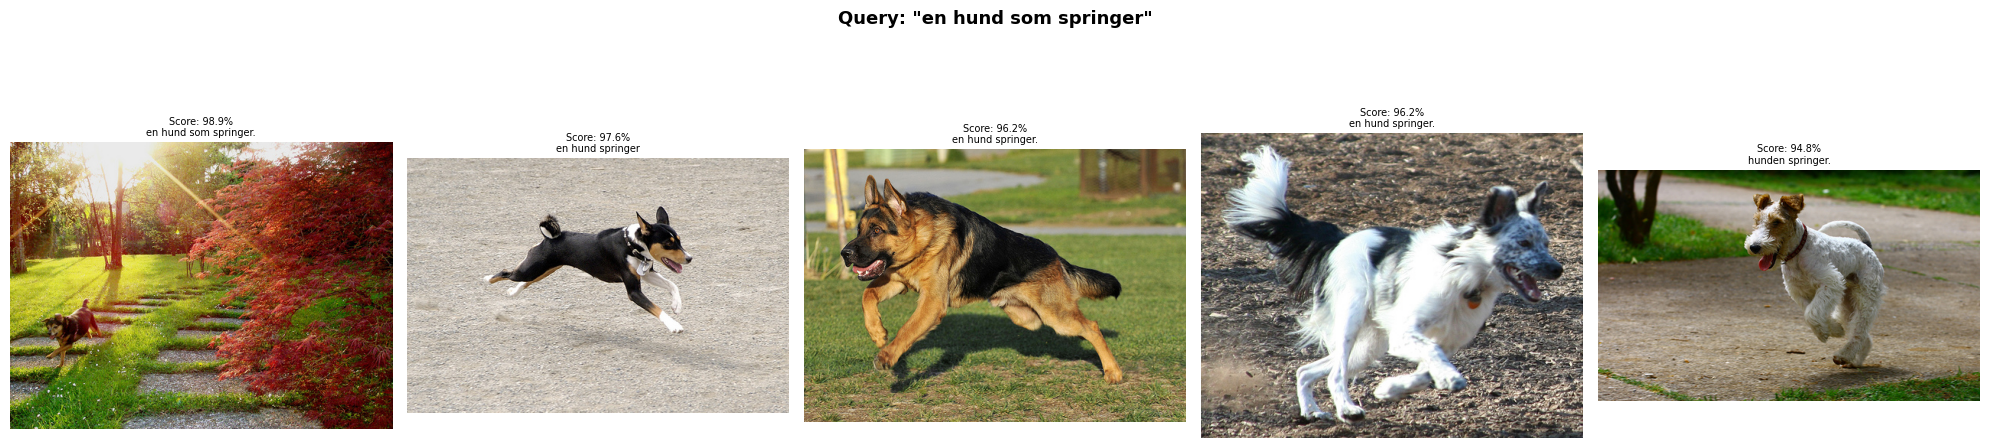


📋 Retrieved 5 images for: 'en hund som springer'
-------------------------------------------------------
  1. Score=0.989 | 2449289139_08fc1092c1.jpg | en hund som springer.
  2. Score=0.976 | 3123463486_f5b36a3624.jpg | en hund springer
  3. Score=0.962 | 3030824089_e5a840265e.jpg | en hund springer.
  4. Score=0.962 | 290019324_23582048d4.jpg | en hund springer.
  5. Score=0.948 | 3488087117_2719647989.jpg | hunden springer.
-------------------------------------------------------


[{'image_path': 'flickr8k/images\\2449289139_08fc1092c1.jpg',
  'caption': 'en hund som springer.',
  'score': 0.9893662929534912,
  'query': 'en hund som springer',
  'source': 'text'},
 {'image_path': 'flickr8k/images\\3123463486_f5b36a3624.jpg',
  'caption': 'en hund springer',
  'score': 0.9763132929801941,
  'query': 'en hund som springer',
  'source': 'text'},
 {'image_path': 'flickr8k/images\\3030824089_e5a840265e.jpg',
  'caption': 'en hund springer.',
  'score': 0.9618552923202515,
  'query': 'en hund som springer',
  'source': 'text'},
 {'image_path': 'flickr8k/images\\290019324_23582048d4.jpg',
  'caption': 'en hund springer.',
  'score': 0.9618552923202515,
  'query': 'en hund som springer',
  'source': 'text'},
 {'image_path': 'flickr8k/images\\3488087117_2719647989.jpg',
  'caption': 'hunden springer.',
  'score': 0.9482210874557495,
  'query': 'en hund som springer',
  'source': 'text'}]

In [29]:
text_search("en hund som springer")

Building manual test set...
Ground truth = ALL images matching keywords

  ✅ 'en hund som springer'
      → 855 valid ground truth images
  ✅ 'barn som leker utomhus'
      → 333 valid ground truth images
  ✅ 'en kvinna på stranden'
      → 53 valid ground truth images
  ✅ 'två män spelar fotboll'
      → 271 valid ground truth images
  ✅ 'en man på cykel'
      → 383 valid ground truth images
  ✅ 'ett barn i vattnet'
      → 129 valid ground truth images
  ✅ 'en häst som hoppar'
      → 12 valid ground truth images
  ✅ 'folk på gatan'
      → 346 valid ground truth images
  ✅ 'en hund i vattnet'
      → 259 valid ground truth images
  ✅ 'barn som klättrar'
      → 297 valid ground truth images
  ✅ 'en person som hoppar'
      → 1194 valid ground truth images
  ✅ 'två hundar leker'
      → 597 valid ground truth images
  ✅ 'en grupp människor'
      → 729 valid ground truth images
  ✅ 'ett barn med en boll'
      → 107 valid ground truth images
  ✅ 'en man som springer'
      → 103 val

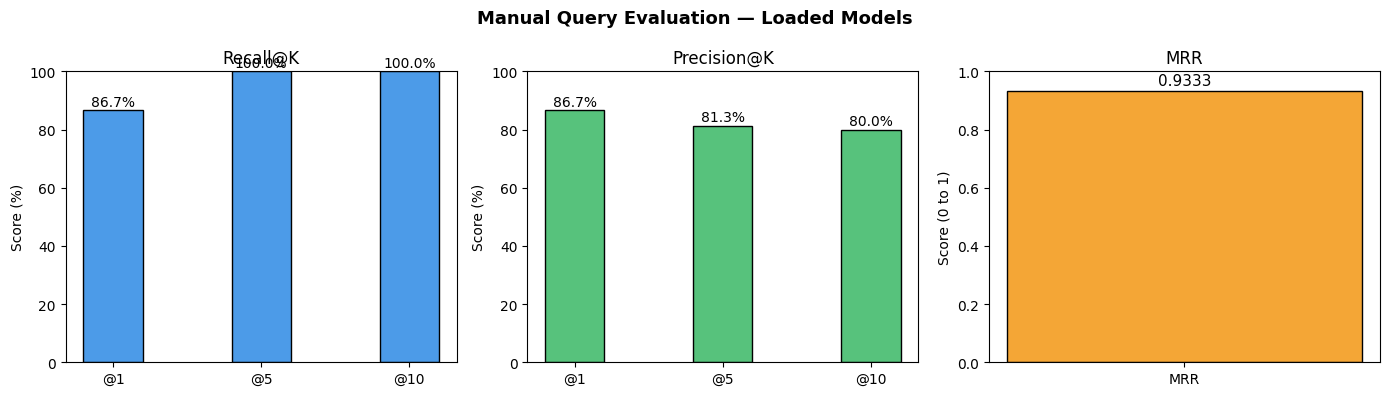

✅ Metrics plot displayed


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import os

# ============================================================
# EVALUATION — MANUAL QUERY TEST ONLY
# Uses multiple ground truth images per query (correct way)
# ============================================================

def build_manual_test_set():
    """
    Builds test set using manually written Swedish queries.
    Ground truth = ALL images whose captions contain the keywords.
    This is the correct way — one query can match many valid images.
    """

    keyword_queries = {
        "en hund som springer"        : ["hund", "springer"],
        "barn som leker utomhus"      : ["barn", "leker"],
        "en kvinna på stranden"       : ["kvinna", "strand"],
        "två män spelar fotboll"      : ["fotboll"],
        "en man på cykel"             : ["cykel"],
        "ett barn i vattnet"          : ["barn", "vatten"],
        "en häst som hoppar"          : ["häst", "hoppar"],
        "folk på gatan"               : ["gatan"],
        "en hund i vattnet"           : ["hund", "vatten"],
        "barn som klättrar"           : ["klättrar"],
        "en person som hoppar"        : ["hoppar"],
        "två hundar leker"            : ["hundar"],
        "en grupp människor"          : ["grupp"],
        "ett barn med en boll"        : ["barn", "boll"],
        "en man som springer"         : ["man", "springer"],
    }

    print("Building manual test set...")
    print("Ground truth = ALL images matching keywords\n")

    test_queries = []
    all_gt_sets  = []   # list of sets — multiple valid images per query

    for query, keywords in keyword_queries.items():

        valid_images = set()

        for img_path, caps in image_to_captions.items():
            for cap in caps:
                if all(kw in cap for kw in keywords):
                    valid_images.add(img_path)
                    break

        if valid_images:
            test_queries.append(query)
            all_gt_sets.append(valid_images)
            print(f"  ✅ '{query}'")
            print(f"      → {len(valid_images)} valid ground truth images")
        else:
            print(f"  ❌ '{query}' → no matching images — skipped")

    print(f"\n✅ Final test set: {len(test_queries)} queries")
    return test_queries, all_gt_sets


# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_manual(
    test_queries,
    all_gt_sets,
    k_values=[1, 5, 10],
    verbose=True
):
    """
    Evaluates using saved models with multiple ground truths per query.
    A result is CORRECT if ANY valid image appears in top K.

    Args:
        test_queries : list of Swedish query strings
        all_gt_sets  : list of sets of valid image paths per query
        k_values     : list of K values to evaluate
        verbose      : print per-query results
    """

    assert len(test_queries) == len(all_gt_sets), \
        "queries and ground truth sets must be same length"

    print("\n" + "="*55)
    print("   MANUAL QUERY EVALUATION")
    print(f"   Embed model  : saved embedding_model")
    print(f"   FAISS index  : {index.ntotal} vectors")
    print(f"   Queries      : {len(test_queries)}")
    print(f"   Ground truth : multiple valid images per query")
    print(f"   K values     : {k_values}")
    print("="*55)

    recall_scores    = {k: [] for k in k_values}
    precision_scores = {k: [] for k in k_values}
    mrr_scores       = []
    rank_list        = []
    max_k            = max(k_values)

    for i, (query, gt_set) in enumerate(
        zip(test_queries, all_gt_sets)
    ):

        # encode query with saved embed_model
        query_vec = embed_model.encode(
            [query],
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype("float32")

        # search saved FAISS index
        scores, indices = index.search(query_vec, max_k * 6)

        # deduplicate results
        retrieved = []
        seen      = set()
        for score, idx in zip(scores[0], indices[0]):
            if idx == -1:
                continue
            img_path = image_paths[idx]
            if img_path in seen:
                continue
            seen.add(img_path)
            retrieved.append(img_path)
            if len(retrieved) == max_k:
                break

        # Recall@K — any valid image in top K?
        for k in k_values:
            hit = int(any(p in gt_set for p in retrieved[:k]))
            recall_scores[k].append(hit)

            hits = sum(1 for p in retrieved[:k] if p in gt_set)
            precision_scores[k].append(hits / k)

        # MRR — rank of first valid image
        rr       = 0.0
        found_at = None
        for rank, path in enumerate(retrieved, start=1):
            if path in gt_set:
                rr       = 1.0 / rank
                found_at = rank
                break

        mrr_scores.append(rr)
        rank_list.append(found_at)

        if verbose:
            status = f"rank {found_at}" if found_at else "NOT FOUND"
            print(f"  [{i+1:2}/{len(test_queries)}]"
                  f"  RR={rr:.3f}"
                  f"  {status:12}"
                  f"  GT={len(gt_set):4} imgs"
                  f"  '{query}'")

    # aggregate metrics
    metrics = {
        "recall_at_k"   : {k: float(np.mean(recall_scores[k]))    for k in k_values},
        "precision_at_k": {k: float(np.mean(precision_scores[k])) for k in k_values},
        "mrr"           : float(np.mean(mrr_scores)),
        "total_queries" : len(test_queries),
        "not_found"     : sum(1 for r in rank_list if r is None),
        "found"         : sum(1 for r in rank_list if r is not None),
        "avg_rank"      : float(np.mean([r for r in rank_list if r is not None]))
                          if any(r for r in rank_list) else 0.0,
    }

    # print results table
    print("\n" + "="*55)
    print("      MANUAL QUERY EVALUATION RESULTS")
    print("="*55)
    print(f"  Total queries   : {metrics['total_queries']}")
    print(f"  Found           : {metrics['found']}")
    print(f"  Not found       : {metrics['not_found']}")
    print(f"  Avg rank        : {metrics['avg_rank']:.1f}")
    print("-"*55)
    for k in k_values:
        r = metrics["recall_at_k"][k]    * 100
        p = metrics["precision_at_k"][k] * 100
        print(f"  Recall@{k:<3}      : {r:.1f}%")
        print(f"  Precision@{k:<3}   : {p:.1f}%")
        print("-"*55)
    print(f"  MRR             : {metrics['mrr']:.4f}")
    print("="*55)

    return metrics


# ============================================================
# PLOT METRICS
# ============================================================

def plot_metrics(metrics, k_values=[1, 5, 10]):
    """
    Plot Recall@K, Precision@K, MRR as bar charts.
    """

    recall_vals    = [metrics["recall_at_k"][k]    * 100 for k in k_values]
    precision_vals = [metrics["precision_at_k"][k] * 100 for k in k_values]
    k_labels       = [f"@{k}" for k in k_values]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(
        "Manual Query Evaluation — Loaded Models",
        fontsize=13,
        fontweight="bold"
    )

    # Recall@K
    axes[0].bar(
        k_labels, recall_vals,
        color="#4C9BE8", edgecolor="black", width=0.4
    )
    axes[0].set_title("Recall@K")
    axes[0].set_ylabel("Score (%)")
    axes[0].set_ylim(0, 100)
    for i, v in enumerate(recall_vals):
        axes[0].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=10)

    # Precision@K
    axes[1].bar(
        k_labels, precision_vals,
        color="#57C27C", edgecolor="black", width=0.4
    )
    axes[1].set_title("Precision@K")
    axes[1].set_ylabel("Score (%)")
    axes[1].set_ylim(0, 100)
    for i, v in enumerate(precision_vals):
        axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=10)

    # MRR
    axes[2].bar(
        ["MRR"],
        [metrics["mrr"]],
        color=["#F4A636"],
        edgecolor="black",
        width=0.3
    )
    axes[2].set_title("MRR")
    axes[2].set_ylabel("Score (0 to 1)")
    axes[2].set_ylim(0, 1)
    axes[2].text(
        0, metrics["mrr"] + 0.02,
        f"{metrics['mrr']:.4f}",
        ha="center", fontsize=11
    )

    plt.tight_layout()
    plt.show()
    print("✅ Metrics plot displayed")


# ============================================================
# RUN
# ============================================================

# step 1 — build test set
test_queries, all_gt_sets = build_manual_test_set()

# step 2 — evaluate
metrics = evaluate_manual(
    test_queries,
    all_gt_sets,
    k_values=[1, 5, 10],
    verbose=True
)

# step 3 — plot
plot_metrics(metrics, k_values=[1, 5, 10])